# U-Net for Image Segmentation: A Practical Tutorial

This tutorial provides a hands-on introduction to **U-Net**, one of the most popular architectures for image segmentation. Originally developed for biomedical image segmentation, U-Net has become the go-to architecture for many segmentation tasks.

We will cover:
- What is U-Net and why it works so well
- Building U-Net from scratch
- Training on a real segmentation task
- Visualising predictions

We Will Cover:

1. **Introduction to U-Net**
   - What is image segmentation?
   - U-Net architecture overview
   - Why U-Net works well

2. **Building U-Net**
   - Encoder path (downsampling)
   - Decoder path (upsampling)
   - Skip connections
   - Complete model

3. **Practical Application**
   - Creating synthetic segmentation data
   - Training the model
   - Evaluating results

4. **Visualisation and Analysis**
   - Visualising predictions
   - Understanding model behavior


By the end of this tutorial, you will be able to:

- Understand the U-Net architecture and its key components
- Implement U-Net from scratch using TensorFlow/Keras
- Train U-Net for image segmentation tasks
- Evaluate and visualise segmentation results
- Apply U-Net to your own segmentation problems

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 1. Introduction to U-Net

### 1.1 What is Image Segmentation?

Image Segmentation is the task of classifying each pixel in an image into a category. Unlike classification (one label per image), segmentation produces a label for every pixel.

| Task | Input | Output |
|------|-------|--------|
| Classification | Image | Single label (e.g., "cat") |
| Object Detection | Image | Bounding boxes + labels |
| **Segmentation** | Image | Pixel-wise labels (mask) |

### 1.2 The U-Net Architecture

U-Net was introduced by Ronneberger et al. (2015) for biomedical image segmentation. Its name comes from its U-shaped architecture:

```
Encoder (Left)                              Decoder (Right) 
     |                                           |          
[64x64x64] ---------------skip-------------> [64x64x64]     
     |                                           |          
[32x32x128] --------------skip-------------> [32x32x128]    
     |                                           |          
[16x16x256] --------------skip-------------> [16x16x256]    
     |                                           |          
[8x8x512] -----------> [8x8x1024] ---------> [8x8x512]      
                       Bottleneck                           
```  

### 1.3 Why U-Net Works So Well

| Feature | Benefit |
|---------|---------|
| **Encoder-Decoder** | Captures both context (what) and location (where) |
| **Skip Connections** | Preserves fine spatial details lost during encoding |
| **Symmetric Design** | Decoder mirrors encoder for precise reconstruction |
| **Works with limited data** | Data augmentation makes it effective for small datasets |

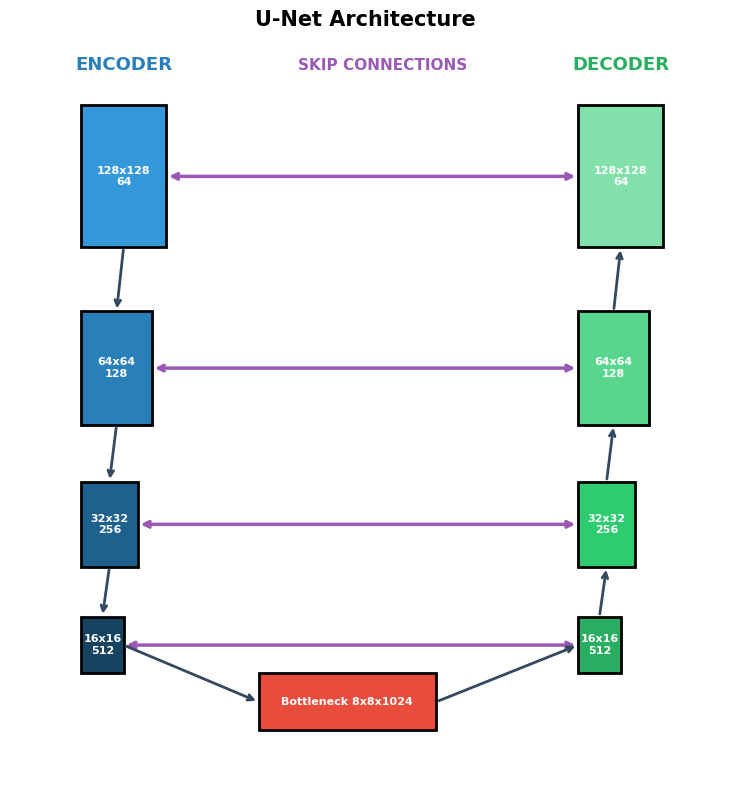

## 2. Building U-Net from Scratch

### 2.1 Encoder Block

The encoder block performs two 3x3 convolutions with ReLU activation, batch normalization for stable training, and max pooling (2x2) to reduce spatial dimensions by half.

In [2]:
def encoder_block(inputs, num_filters):
    """
    Encoder block: Conv -> BN -> ReLU -> Conv -> BN -> ReLU -> MaxPool

    Returns:
        skip: Feature map before pooling (for skip connection)
        pool: Feature map after pooling (for next block)
    """
    # First convolution
    x = layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Second convolution
    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Save for skip connection (before pooling)
    skip = x

    # Pooling to reduce spatial dimensions
    pool = layers.MaxPooling2D(pool_size=(2, 2))(x)

    return skip, pool

# Test encoder block
test_input = layers.Input(shape=(128, 128, 3))
skip, pooled = encoder_block(test_input, 64)
print(f"Input:  {test_input.shape}")
print(f"Skip:   {skip.shape}  (saved for decoder)")
print(f"Pooled: {pooled.shape}  (goes to next encoder block)")

Input:  (None, 128, 128, 3)
Skip:   (None, 128, 128, 64)  (saved for decoder)
Pooled: (None, 64, 64, 64)  (goes to next encoder block)


### 2.2 Decoder Block

The decoder block performs upsampling (transposed convolution), concatenates with the skip connection from the encoder, then applies two convolutions.

In [3]:
def decoder_block(inputs, skip_connection, num_filters):
    """
    Decoder block: UpConv -> Concat(skip) -> Conv -> BN -> ReLU -> Conv -> BN -> ReLU

    Args:
        inputs: Feature map from previous decoder block or bottleneck
        skip_connection: Feature map from corresponding encoder block
        num_filters: Number of filters
    """
    # Upsample using transposed convolution
    x = layers.Conv2DTranspose(num_filters, 2, strides=2, padding='same')(inputs)

    # Concatenate with skip connection from encoder
    x = layers.Concatenate()([x, skip_connection])

    # First convolution
    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Second convolution
    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    return x

# Test decoder block
bottleneck = layers.Input(shape=(8, 8, 1024))
skip = layers.Input(shape=(16, 16, 512))
decoded = decoder_block(bottleneck, skip, 512)
print(f"Bottleneck input: {bottleneck.shape}")
print(f"Skip connection:  {skip.shape}")
print(f"Decoded output:   {decoded.shape}")

Bottleneck input: (None, 8, 8, 1024)
Skip connection:  (None, 16, 16, 512)
Decoded output:   (None, 16, 16, 512)


### 2.3 Complete U-Net Model

Now let us put it all together into a complete U-Net model:

In [4]:
def build_unet(input_shape=(128, 128, 3), num_classes=1):
    """
    Build complete U-Net model for image segmentation.

    Args:
        input_shape: Shape of input images (H, W, C)
        num_classes: Number of output classes (1 for binary segmentation)

    Returns:
        model: Keras Model
    """
    inputs = layers.Input(shape=input_shape)

    # ============ ENCODER ============
    # Block 1: 128x128 -> 64x64
    s1, p1 = encoder_block(inputs, 64)

    # Block 2: 64x64 -> 32x32
    s2, p2 = encoder_block(p1, 128)

    # Block 3: 32x32 -> 16x16
    s3, p3 = encoder_block(p2, 256)

    # Block 4: 16x16 -> 8x8
    s4, p4 = encoder_block(p3, 512)

    # ============ BOTTLENECK ============
    # 8x8 with 1024 filters
    b = layers.Conv2D(1024, 3, padding='same')(p4)
    b = layers.BatchNormalization()(b)
    b = layers.ReLU()(b)
    b = layers.Conv2D(1024, 3, padding='same')(b)
    b = layers.BatchNormalization()(b)
    b = layers.ReLU()(b)

    # ============ DECODER ============
    # Block 1: 8x8 -> 16x16
    d1 = decoder_block(b, s4, 512)

    # Block 2: 16x16 -> 32x32
    d2 = decoder_block(d1, s3, 256)

    # Block 3: 32x32 -> 64x64
    d3 = decoder_block(d2, s2, 128)

    # Block 4: 64x64 -> 128x128
    d4 = decoder_block(d3, s1, 64)

    # ============ OUTPUT ============
    if num_classes == 1:
        outputs = layers.Conv2D(1, 1, activation='sigmoid')(d4)
    else:
        outputs = layers.Conv2D(num_classes, 1, activation='softmax')(d4)

    model = Model(inputs, outputs, name='UNet')
    return model

# Build the model
model = build_unet(input_shape=(128, 128, 3), num_classes=1)
print(f"Model: {model.name}")
print(f"Input shape:  {model.input_shape}")
print(f"Output shape: {model.output_shape}")
print(f"Total parameters: {model.count_params():,}")

Model: UNet
Input shape:  (None, 128, 128, 3)
Output shape: (None, 128, 128, 1)
Total parameters: 31,055,297


In [5]:
# Display model summary
model.summary()

Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │     36,928 │ re_lu_4[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_5[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    147,584 │ re_lu_6[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ re_lu_7[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_8[0][0]  

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

## 3. Practical Application

### 3.1 Creating Synthetic Segmentation Data

For this demo, we will create synthetic images with shapes (circles, rectangles) and their corresponding segmentation masks:

In [ ]:
def create_segmentation_data(num_samples=500, img_size=128):
    """
    Create synthetic images with shapes and their segmentation masks.

    Returns:
        X: Images with colored shapes on noisy backgrounds
        y: Binary masks (1 where shapes are, 0 elsewhere)
    """
    X = np.zeros((num_samples, img_size, img_size, 3), dtype=np.float32)
    y = np.zeros((num_samples, img_size, img_size, 1), dtype=np.float32)

    for i in range(num_samples):
        # Random noisy background
        X[i] = np.random.rand(img_size, img_size, 3) * 0.3

        # Add 2-4 random circles
        num_shapes = np.random.randint(2, 5)
        for _ in range(num_shapes):
            # Random circle parameters
            cx = np.random.randint(20, img_size - 20)
            cy = np.random.randint(20, img_size - 20)
            radius = np.random.randint(10, 30)
            color = np.random.rand(3) * 0.5 + 0.5  # Bright colors

            # Create circle
            yy, xx = np.ogrid[:img_size, :img_size]
            circle = ((xx - cx)**2 + (yy - cy)**2) <= radius**2

            # Add to image and mask
            X[i][circle] = color
            y[i][circle, 0] = 1.0

    return X, y

# Generate data
print("Generating synthetic segmentation data...")
X_train, y_train = create_segmentation_data(num_samples=800, img_size=128)
X_val, y_val = create_segmentation_data(num_samples=200, img_size=128)

print(f"Training set:   {X_train.shape} images, {y_train.shape} masks")
print(f"Validation set: {X_val.shape} images, {y_val.shape} masks")

Generating synthetic segmentation data...
Training set:   (800, 128, 128, 3) images, (800, 128, 128, 1) masks
Validation set: (200, 128, 128, 3) images, (200, 128, 128, 1) masks


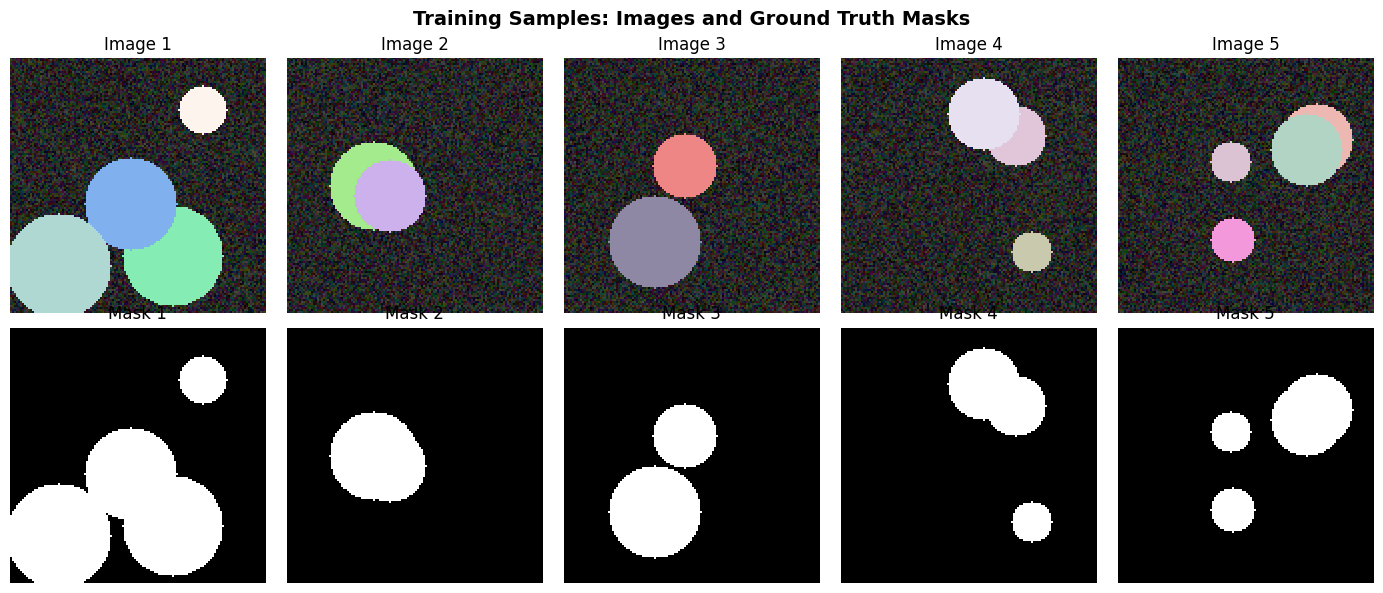

In [ ]:
# Visualize some training samples
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i in range(5):
    axes[0, i].imshow(X_train[i])
    axes[0, i].set_title(f'Image {i+1}')
    axes[0, i].axis('off')

    axes[1, i].imshow(y_train[i, :, :, 0], cmap='gray')
    axes[1, i].set_title(f'Mask {i+1}')
    axes[1, i].axis('off')

plt.suptitle('Training Samples: Images and Ground Truth Masks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Training the Model

We will use Binary Cross-Entropy loss and the Dice coefficient as our primary metric for segmentation quality.

In [ ]:
# Define Dice coefficient metric
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """
    Dice coefficient: measures overlap between prediction and ground truth.
    Score of 1.0 = perfect match, 0.0 = no overlap
    """
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

# Build and compile model
model = build_unet(input_shape=(128, 128, 3), num_classes=1)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coefficient]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
# Train the model
print("Training U-Net...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16,
    verbose=1
)

Training U-Net...
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 413ms/step - accuracy: 0.9627 - dice_coefficient: 0.8318 - loss: 0.1168 - val_accuracy: 0.6511 - val_dice_coefficient: 0.4917 - val_loss: 0.5909
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 245ms/step - accuracy: 0.9998 - dice_coefficient: 0.9749 - loss: 0.0106 - val_accuracy: 0.8187 - val_dice_coefficient: 0.5417 - val_loss: 0.4637
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 248ms/step - accuracy: 1.0000 - dice_coefficient: 0.9875 - loss: 0.0051 - val_accuracy: 0.7543 - val_dice_coefficient: 0.5294 - val_loss: 0.5163
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 251ms/step - accuracy: 1.0000 - dice_coefficient: 0.9924 - loss: 0.0031 - val_accuracy: 0.8698 - val_dice_coefficient: 0.5696 - val_loss: 0.4275
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 252ms/step - accuracy: 1.0000 - dice_coefficient: 0.9948 - loss: 0.0021 - val_accuracy: 0.9600 - val_dice_coefficient: 0.6714 - val_loss: 0.2610
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 249ms

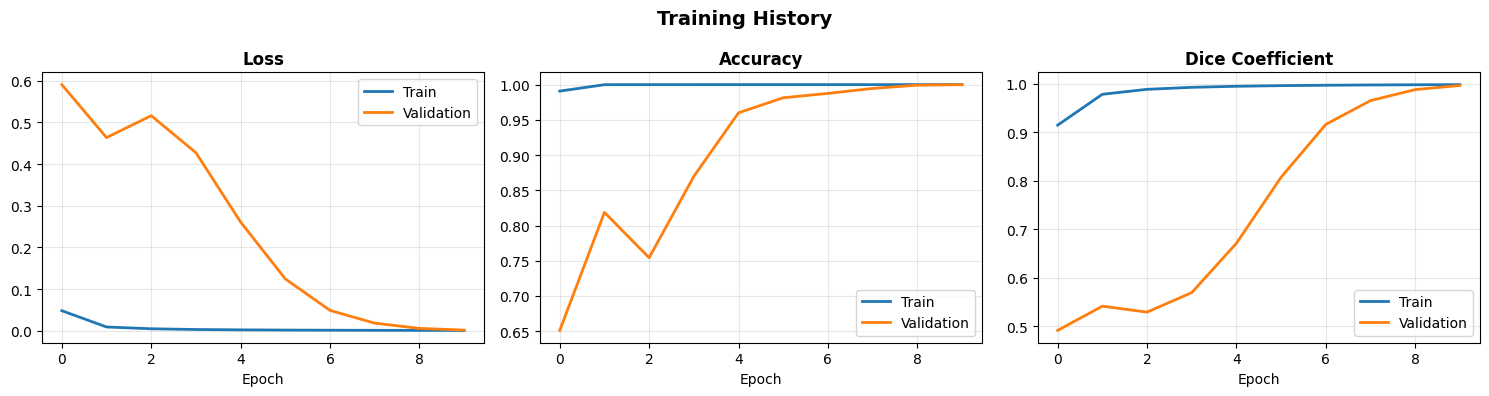

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history.history['loss'], label='Train', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0].set_title('Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[1].set_title('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Dice Coefficient
axes[2].plot(history.history['dice_coefficient'], label='Train', linewidth=2)
axes[2].plot(history.history['val_dice_coefficient'], label='Validation', linewidth=2)
axes[2].set_title('Dice Coefficient', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Visualisation and Analysis

### 4.1 Visualising Predictions

Let us see how well our trained model segments the validation images:

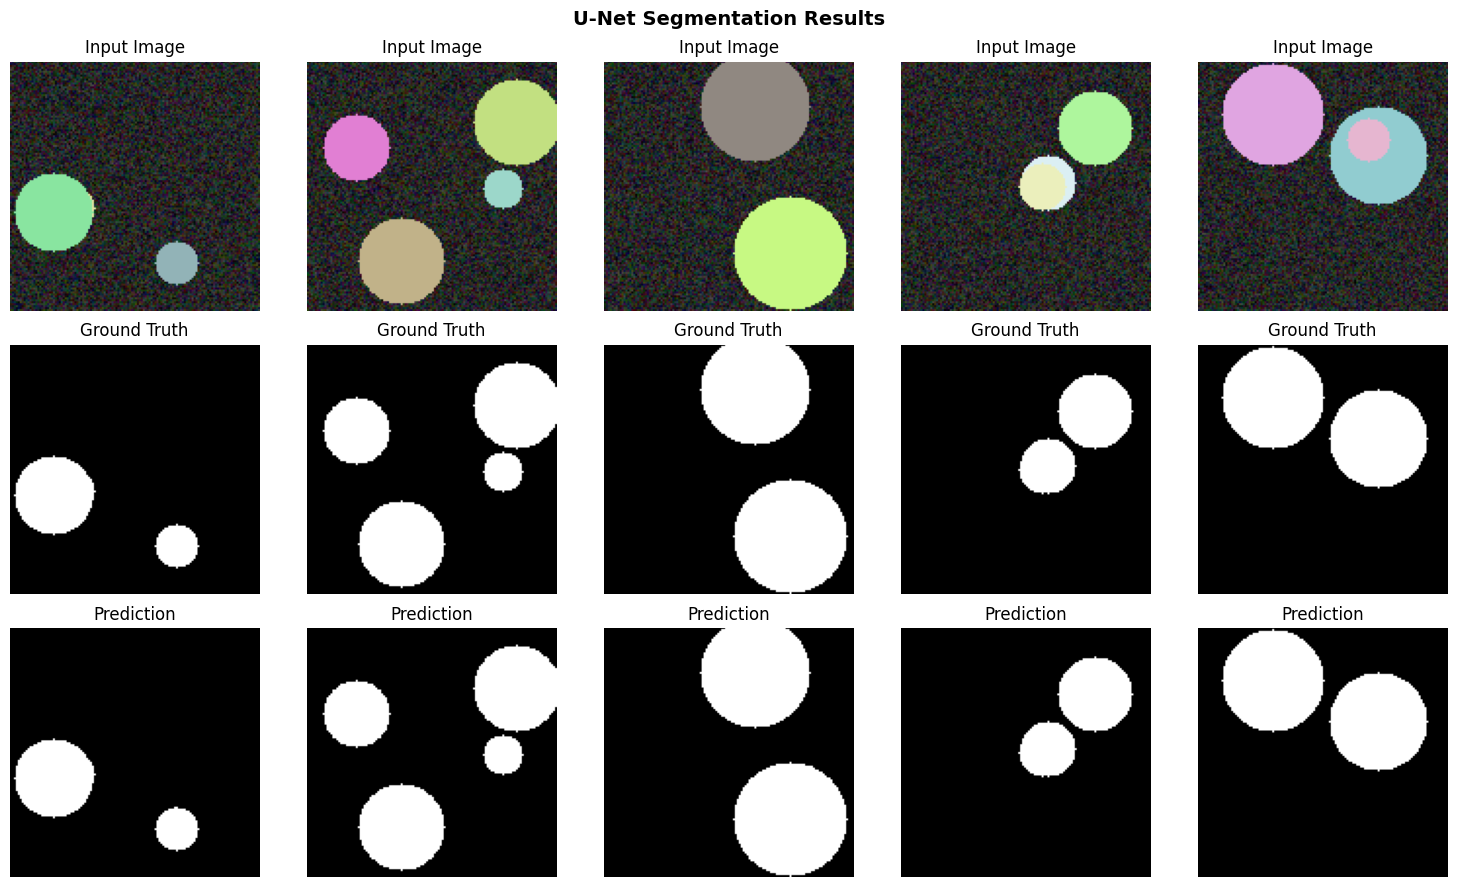

In [ ]:
# Make predictions on validation set
predictions = model.predict(X_val[:10], verbose=0)

# Visualize results
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for i in range(5):
    # Original image
    axes[0, i].imshow(X_val[i])
    axes[0, i].set_title('Input Image')
    axes[0, i].axis('off')

    # Ground truth mask
    axes[1, i].imshow(y_val[i, :, :, 0], cmap='gray')
    axes[1, i].set_title('Ground Truth')
    axes[1, i].axis('off')

    # Predicted mask (thresholded at 0.5)
    pred_mask = (predictions[i, :, :, 0] > 0.5).astype(np.float32)
    axes[2, i].imshow(pred_mask, cmap='gray')
    axes[2, i].set_title('Prediction')
    axes[2, i].axis('off')

plt.suptitle('U-Net Segmentation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Overlay Visualisation

Let us overlay the predicted masks on the original images to better see the segmentation quality:

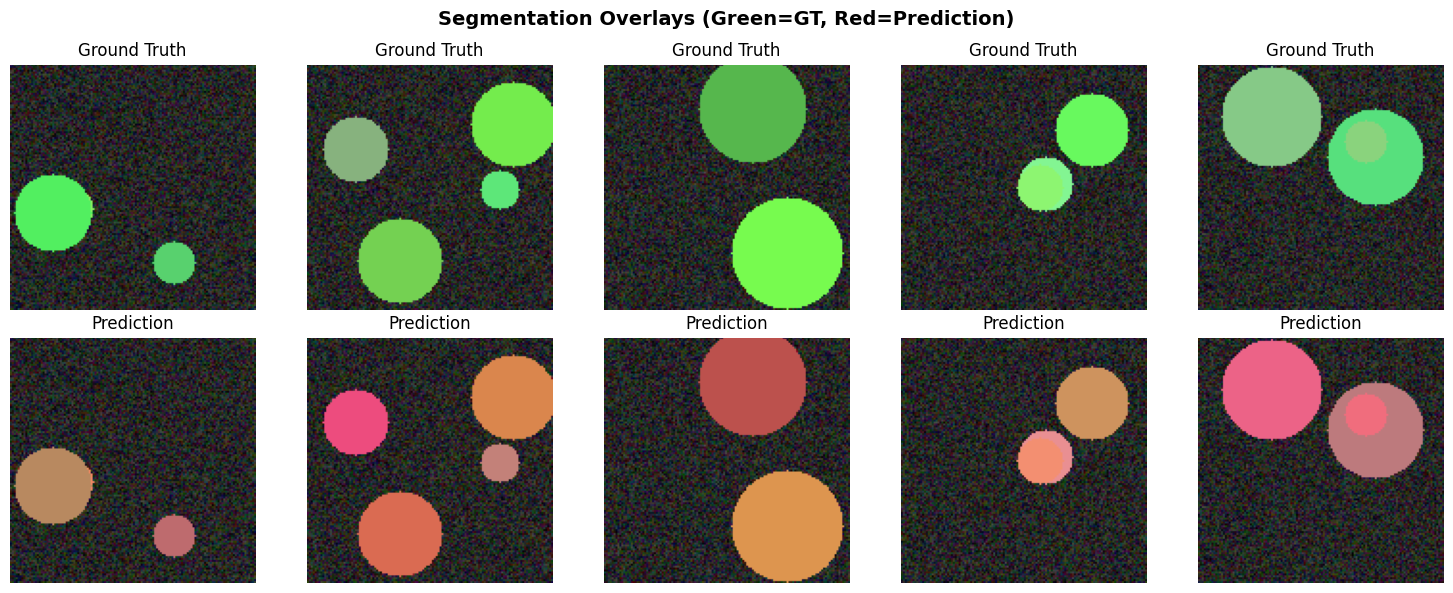

In [ ]:
def create_overlay(image, mask, alpha=0.4, color=[1, 0, 0]):
    """Create an overlay of mask on image with specified color."""
    overlay = image.copy()
    mask_bool = mask > 0.5

    for c in range(3):
        overlay[:, :, c] = np.where(
            mask_bool,
            overlay[:, :, c] * (1 - alpha) + color[c] * alpha,
            overlay[:, :, c]
        )
    return overlay

# Create overlays
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    # Ground truth overlay (green)
    gt_overlay = create_overlay(X_val[i], y_val[i, :, :, 0], color=[0, 1, 0])
    axes[0, i].imshow(gt_overlay)
    axes[0, i].set_title('Ground Truth')
    axes[0, i].axis('off')

    # Prediction overlay (red)
    pred_mask = (predictions[i, :, :, 0] > 0.5).astype(np.float32)
    pred_overlay = create_overlay(X_val[i], pred_mask, color=[1, 0, 0])
    axes[1, i].imshow(pred_overlay)
    axes[1, i].set_title('Prediction')
    axes[1, i].axis('off')

plt.suptitle('Segmentation Overlays (Green=GT, Red=Prediction)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Conclusion

In this tutorial, we built a complete **U-Net** model for image segmentation from scratch.

### Key Components of U-Net

| Component | Purpose |
|-----------|---------|
| **Encoder** | Extracts features and reduces spatial dimensions |
| **Bottleneck** | Captures high-level semantic information |
| **Decoder** | Reconstructs spatial dimensions |
| **Skip Connections** | Preserve fine details from encoder to decoder |
| **Output Layer** | Produces pixel-wise class predictions |


#### What Makes U-Net Effective

1. **Symmetric architecture** ensures decoder can reconstruct precise boundaries
2. **Skip connections** preserve spatial information lost during encoding
3. **Works well with limited data** due to built-in regularization
4. **Flexible** - can handle different image sizes and number of classes


### Real-World Applications

| Domain | Application |
|--------|-------------|
| **Medical Imaging** | Organ segmentation, tumor detection, cell counting |
| **Autonomous Vehicles** | Road segmentation, obstacle detection |
| **Satellite Imagery** | Land use classification, building detection |
| **Agriculture** | Crop health monitoring, weed detection |